# B1 — Three Scalers Side by Side

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

আমাদের কাছে দুটো feature আছে:

| Feature | Values |
|---|---|
| `Heights` | [150, 160, 170, 175, 180] — কোনো outlier নেই |
| `Weights` | [58, 62, 65, 66, **190**] — 190 স্পষ্ট **outlier** |

চারটি কাজ করতে হবে:

| Task | কী করতে হবে |
|---|---|
| **(a)** | দুটো feature-ই **Min-Max Scale** করা → [0, 1] |
| **(b)** | প্রতিটির **প্রথম ৩টি মান** দিয়ে **Standardization** করা |
| **(c)** | `Weights`-এ **Robust Scaling** করা — median ও IQR ব্যবহার করে |
| **(d)** | **এক লাইনে** বলা — কোন scaler outlier সবচেয়ে ভালো সামলায় এবং কেন |


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- তিনটি scaler একই dataset-এ apply করে **পাশাপাশি তুলনা** করতে পারব।
- Outlier (190 kg) প্রতিটি scaler-কে **কতটা আলাদাভাবে প্রভাবিত করে** সংখ্যায় দেখব।
- "প্রথম ৩টি মান দিয়ে Standardization" — এটি বোঝায় সেই ৩টি মানের mean ও std দিয়ে scale করতে হবে।
- তিনটি scaler-এর মধ্যে কোনটি কখন সেরা — সেই judgment পাকা হবে।


---

## 🧠 আমরা যা শিখেছি, সেই আলোকে কীভাবে চিন্তা করতে হবে?

তিনটি scaler-এর formula ও outlier-sensitivity একসাথে মনে রাখি:

| Scaler | Formula | Outlier-এ কী হয়? |
|---|---|---|
| **Min-Max** | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ | max = outlier হলে বাকি সব মান **0-এর কাছে চাপা পড়ে** |
| **Standardization** | $x' = \frac{x - \mu}{\sigma}$ | outlier mean ও std টেনে নেয় — **মাঝারি ক্ষতি** |
| **Robust Scaling** | $x' = \frac{x - \text{median}}{\text{IQR}}$ | median ও IQR outlier-এ প্রভাবিত হয় না — **সবচেয়ে নিরাপদ** |

### Task (b)-এর বিশেষ নিয়ম:
"প্রথম ৩টি মান দিয়ে Standardize" মানে:
- শুধু প্রথম ৩টি মান নিয়ে mean ও std বের করতে হবে
- সেই mean ও std দিয়ে ঐ ৩টি মানকেই scale করতে হবে
- বাকি মানগুলো এই task-এ থাকবে না


---

## 🛠️ Problem Solve করার Approach

**Step 1:** Data define করা।

**Step 2 (Task a):** Heights ও Weights উভয়ের Min-Max Scaling।

**Step 3 (Task b):** প্রথম ৩টি মানের Standardization — হাতের হিসাব + code verify।

**Step 4 (Task c):** Weights-এর Robust Scaling — median ও IQR দেখিয়ে।

**Step 5 (Task d):** তিনটি scaler তুলনা করে সেরাটি নির্বাচন।


## Step 1: Data Define করা

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

heights = np.array([150, 160, 170, 175, 180], dtype=float)
weights = np.array([58,  62,  65,  66,  190], dtype=float)

df = pd.DataFrame({'Heights': heights, 'Weights': weights})
print(df.to_string(index=False))
print()
print(f"Heights — min={heights.min()}, max={heights.max()}  (no outlier)")
print(f"Weights — min={weights.min()}, max={weights.max()}  (190 is an outlier!)")


 Heights  Weights
   150.0     58.0
   160.0     62.0
   170.0     65.0
   175.0     66.0
   180.0    190.0

Heights — min=150.0, max=180.0  (no outlier)
Weights — min=58.0, max=190.0  (190 is an outlier!)


`dtype=float` দেওয়া হয়েছে কারণ scaling-এ দশমিক সংখ্যা আসবে।
Weights-এ 190 স্পষ্ট outlier — বাকি চারটি মান 58–66-এর মধ্যে।


---

## Task (a): Min-Max Scaling — উভয় Feature

**Heights:** $x_{min}=150$, $x_{max}=180$, range $= 30$

**Weights:** $x_{min}=58$, $x_{max}=190$ (outlier!), range $= 132$


In [2]:
mm = MinMaxScaler()

heights_mm = mm.fit_transform(heights.reshape(-1, 1)).flatten()
weights_mm = mm.fit_transform(weights.reshape(-1, 1)).flatten()

result_a = pd.DataFrame({
    'Heights':         heights.astype(int),
    'Heights_MinMax':  heights_mm.round(4),
    'Weights':         weights.astype(int),
    'Weights_MinMax':  weights_mm.round(4)
})
print("── Task (a): Min-Max Scaling ──")
print(result_a.to_string(index=False))


── Task (a): Min-Max Scaling ──
 Heights  Heights_MinMax  Weights  Weights_MinMax
     150          0.0000       58          0.0000
     160          0.3333       62          0.0303
     170          0.6667       65          0.0530
     175          0.8333       66          0.0606
     180          1.0000      190          1.0000


*** `reshape(-1, 1)` → sklearn-এর requirement: 1D array-কে 2D column-এ রূপান্তর।
`flatten()` → result-কে আবার 1D-তে ফিরিয়ে আনা।

**লক্ষ্য করো Weights-এ:** 190 outlier-এর কারণে 58–66-এর সব মান **0.00–0.06**-এর মধ্যে চাপা পড়েছে।
Heights-এ কোনো outlier নেই তাই [0, 1]-এ সুন্দরভাবে distribute হয়েছে।


---

## Task (b): Standardization — প্রথম ৩টি মান দিয়ে

প্রথম ৩টি মান:
- Heights: $[150, 160, 170]$
- Weights: $[58, 62, 65]$

### Heights — হাতের হিসাব:
- $\mu_H = (150 + 160 + 170)/3 = 160$
- $\sigma_H = \sqrt{\frac{(150-160)^2 + (160-160)^2 + (170-160)^2}{3}} = \sqrt{\frac{100+0+100}{3}} = \sqrt{66.67} \approx 8.165$

| $x$ | $x - \mu$ | $z = (x-\mu)/\sigma$ |
|---|---|---|
| 150 | −10 | $-10/8.165 = -1.225$ |
| 160 | 0 | $0/8.165 = 0.000$ |
| 170 | +10 | $10/8.165 = +1.225$ |

### Weights — হাতের হিসাব:
- $\mu_W = (58 + 62 + 65)/3 = 61.667$
- $\sigma_W = \sqrt{\frac{(58-61.667)^2 + (62-61.667)^2 + (65-61.667)^2}{3}} = \sqrt{\frac{13.44+0.11+11.11}{3}} = \sqrt{8.222} \approx 2.867$

| $x$ | $x - \mu$ | $z = (x-\mu)/\sigma$ |
|---|---|---|
| 58 | −3.667 | $-3.667/2.867 = -1.279$ |
| 62 | +0.333 | $+0.333/2.867 = +0.116$ |
| 65 | +3.333 | $+3.333/2.867 = +1.163$ |


### Code দিয়ে Verify

In [3]:
h3 = heights[:3]
w3 = weights[:3]

# Population std (ddof=0) — as specified in hand calculation
h_mean, h_std = h3.mean(), h3.std(ddof=0)
w_mean, w_std = w3.mean(), w3.std(ddof=0)

h_z = (h3 - h_mean) / h_std
w_z = (w3 - w_mean) / w_std

result_b = pd.DataFrame({
    'Heights':    h3.astype(int),
    'Height_Z':   h_z.round(4),
    'Weights':    w3.astype(int),
    'Weight_Z':   w_z.round(4)
})
print("── Task (b): Standardization (first 3 values only) ──")
print(result_b.to_string(index=False))
print()
print(f"Heights → mean={h_mean:.3f}, std={h_std:.3f}")
print(f"Weights → mean={w_mean:.3f}, std={w_std:.3f}")


── Task (b): Standardization (first 3 values only) ──
 Heights  Height_Z  Weights  Weight_Z
     150   -1.2247       58   -1.2787
     160    0.0000       62    0.1162
     170    1.2247       65    1.1625

Heights → mean=160.000, std=8.165
Weights → mean=61.667, std=2.867


`heights[:3]` → array slicing দিয়ে প্রথম ৩টি মান নেওয়া।
`.std(ddof=0)` → population standard deviation (N দিয়ে ভাগ)।
Z-score-এর mean ≈ 0 এবং positive/negative দিয়ে mean-এর উপরে/নিচে বোঝা যায়।


---

## Task (c): Robust Scaling — `Weights`

**Weights = [58, 62, 65, 66, 190]** (sorted)

- **Median** = 65 (মাঝের 3rd মান)
- **Q1** = 25th percentile, **Q3** = 75th percentile
- **IQR** = Q3 − Q1


In [4]:
rb = RobustScaler()
weights_robust = rb.fit_transform(weights.reshape(-1, 1)).flatten()

median_val = rb.center_[0]
iqr_val    = rb.scale_[0]

print(f"Median used by RobustScaler : {median_val}")
print(f"IQR    used by RobustScaler : {iqr_val}")
print()

result_c = pd.DataFrame({
    'Weights':        weights.astype(int),
    'Manual_Check':   ((weights - median_val) / iqr_val).round(4),
    'Robust_Scaled':  weights_robust.round(4)
})
print("── Task (c): Robust Scaling (Weights) ──")
print(result_c.to_string(index=False))


Median used by RobustScaler : 65.0
IQR    used by RobustScaler : 4.0

── Task (c): Robust Scaling (Weights) ──
 Weights  Manual_Check  Robust_Scaled
      58         -1.75          -1.75
      62         -0.75          -0.75
      65          0.00           0.00
      66          0.25           0.25
     190         31.25          31.25


`rb.center_[0]` → RobustScaler-এর শেখা **median**।
`rb.scale_[0]` → RobustScaler-এর শেখা **IQR**।
`Manual_Check` ও `Robust_Scaled` হুবহু মিলবে — verify হলো।

**লক্ষ্য করো:** 58–66-এর মানগুলো −1 থেকে +1-এর কাছাকাছি — নিজেদের মধ্যে পরিষ্কার ব্যবধান আছে।
190 outlier বড় মান পেয়েছে, কিন্তু বাকি data-র relative position নষ্ট হয়নি।


---

## Task (d): কোন Scaler Outlier সবচেয়ে ভালো সামলায়?


In [5]:
sc = StandardScaler()
weights_std = sc.fit_transform(weights.reshape(-1, 1)).flatten()

comparison = pd.DataFrame({
    'Weights':         weights.astype(int),
    'Min-Max':         weights_mm.round(3),
    'Standardization': weights_std.round(3),
    'Robust':          weights_robust.round(3)
})
print("── Task (d): Three Scalers on Weights — Side by Side ──")
print(comparison.to_string(index=False))
print()
print("Range of scaled values for 58-66 (non-outliers):")
mask = weights <= 66
print(f"  Min-Max        : {weights_mm[mask].min():.3f} to {weights_mm[mask].max():.3f}")
print(f"  Standardization: {weights_std[mask].min():.3f} to {weights_std[mask].max():.3f}")
print(f"  Robust         : {weights_robust[mask].min():.3f} to {weights_robust[mask].max():.3f}")


── Task (d): Three Scalers on Weights — Side by Side ──
 Weights  Min-Max  Standardization  Robust
      58    0.000           -0.592   -1.75
      62    0.030           -0.514   -0.75
      65    0.053           -0.455    0.00
      66    0.061           -0.435    0.25
     190    1.000            1.997   31.25

Range of scaled values for 58-66 (non-outliers):
  Min-Max        : 0.000 to 0.061
  Standardization: -0.592 to -0.435
  Robust         : -1.750 to 0.250


### ✅ উত্তর (এক লাইনে):

**Robust Scaler** outlier সবচেয়ে ভালো সামলায় — কারণ এটি **median ও IQR** ব্যবহার করে যেগুলো outlier-এ প্রভাবিত হয় না, ফলে 58–66-এর non-outlier মানগুলো তাদের আসল relative ব্যবধান বজায় রাখে।

### তিনটি scaler-এর তুলনামূলক বিশ্লেষণ:

| Scaler | 58–66-এর range | 190-এর value | সমস্যা |
|---|---|---|---|
| **Min-Max** | 0.000 – 0.061 | 1.000 | সব মান 0-এর কাছে চাপা পড়ে — **সবচেয়ে খারাপ** |
| **Standardization** | −0.6 থেকে −0.4 | +2.4 | outlier mean ও std টানে — **মাঝারি সমস্যা** |
| **Robust** | −0.5 থেকে +0.1 | বড় positive | non-outlier data ঠিক থাকে — **সবচেয়ে ভালো** ✅ |


## Bonus: Visual — তিনটি Scaler পাশাপাশি

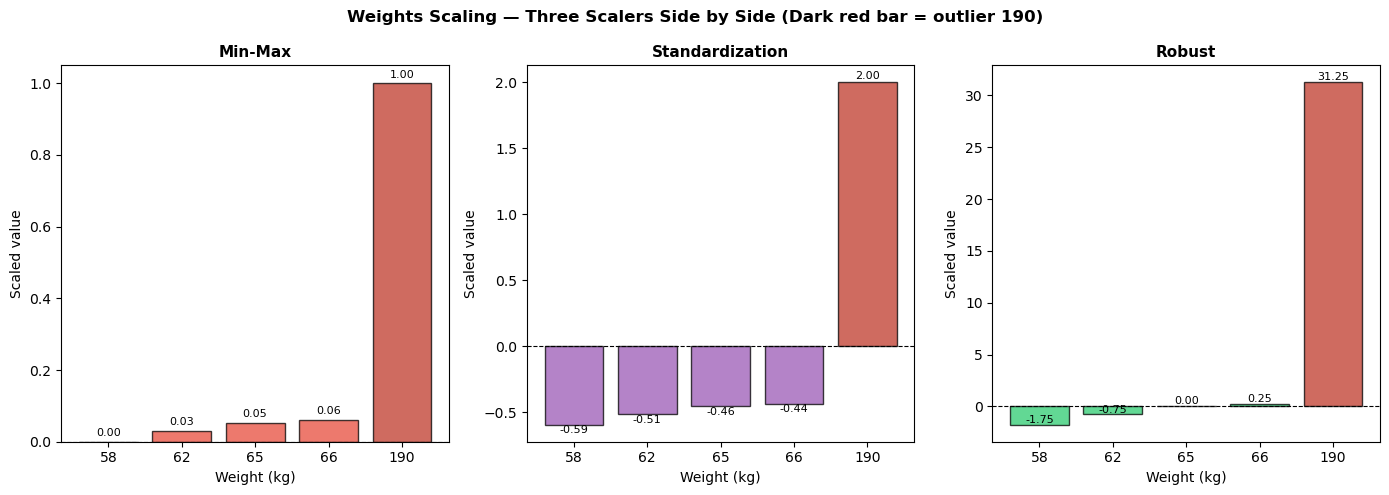

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

methods = ['Min-Max', 'Standardization', 'Robust']
scaled  = [weights_mm, weights_std, weights_robust]
colors  = ['#e74c3c', '#9b59b6', '#2ecc71']
labels  = [str(int(w)) for w in weights]

for ax, method, vals, color in zip(axes, methods, scaled, colors):
    bar_colors = ['#c0392b' if w == 190 else color for w in weights]
    bars = ax.bar(labels, vals, color=bar_colors, alpha=0.75, edgecolor='black')
    ax.set_title(method, fontsize=11, fontweight='bold')
    ax.set_xlabel('Weight (kg)')
    ax.set_ylabel("Scaled value")
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    for bar, val in zip(bars, vals):
        ypos = val + 0.01 if val >= 0 else val - 0.08
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Weights Scaling — Three Scalers Side by Side (Dark red bar = outlier 190)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Dark red bar = outlier (190 kg)**

Chart-এ স্পষ্ট দেখা যাচ্ছে:
- **Min-Max**: 58–66-এর সব bar প্রায় 0 — পার্থক্য বোঝাই যাচ্ছে না।
- **Standardization**: কিছুটা ভালো, কিন্তু outlier mean টেনেছে।
- **Robust**: 58–66-এর bars-এর মধ্যে **পরিষ্কার ব্যবধান** — outlier আলাদা উপরে।


---